In [1]:
import sys, os
sys.path.insert(1, os.path.realpath(os.path.pardir))
from specs import *
import pandas as pd
from scipy.optimize import curve_fit
from scipy.stats import t
from matplotlib.transforms import ScaledTranslation
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica"
})

rawDir = "/Users/jiyong/data/0804_container_detector_data/"
pn1Dir = rawDir + "P1_SN1222/"
pn2Dir = rawDir + "P2_SN1215/"
pn1files0 = [f for f in listdir(pn1Dir) if isfile(join(pn1Dir, f)) and f.endswith('mca')]
pn2files0 = [f for f in listdir(pn2Dir) if isfile(join(pn2Dir, f)) and f.endswith('mca')]

pn1files = [None] * len(pn1files0)
pn2files = [None] * len(pn2files0)

for f1 in pn1files0:
    ddd = (f1[1:-4].split("_"))[-1]
    if ddd == "BKG":
        pn1files[0] = pn1Dir+f1
    else :
        q = int(ddd.split("-")[-1])
        pn1files[q] = pn1Dir+f1
for f2 in pn2files0:
    ddd = (f2[1:-4].split("_"))[-1]
    if ddd == "BKG":
        pn2files[0] = pn2Dir+f2
    else :
        q = int(ddd.split("-")[-1])
        pn2files[q] = pn2Dir+f2


Log =[
    [0, ["Bkg"], 0, 0],                            # 0
    [1, ["Am241",], 80, 420],                      # 1
    [2, ["Am241",], 180, 320],                     # 2
    [3, ["Am241",], 280, 220],                     # 3
    [4, ["Am241",], 460, 40],                      # 4
    [5, ["Cs137",], 70, 430],                      # 5
    [6, ["Cs137",], 130, 370],                     # 6
    [7, ["Cs137",], 300, 200],                     # 7
    [8, ["Cs137",], 390, 110],                     # 8
    [9, ["Co60",], 60, 440],                       # 9
    [10, ["Co60",], 120, 380],                      # 10
    [11, ["Co60",], 310, 190],                      # 11
    [12, ["Co60",], 470, 30],                       # 12
    [13, ["Co60", "Cs137"], 136, 359],              # 13
    [14, ["Am241", "Co60"], 287, 208],              # 14
    [15, ["Co60", "Cs137"], 361, 134],              # 15
    [16, ["Am241", "Cs137"], 163, 332],
    [17, ["Am241", "Co60", "Cs137"], 309, 186],
    [18, ["Am241", "Co60",], 210, 285, 153, 342],
    [19, ["Co60", "Cs137"], 285, 210, 367, 128],
    [20, ["Am241", "Cs137"], 85, 410, 173, 322],
    [21, ["Co60", "Cs137"], 316, 179, 223, 272],
    [22, [None,], ],
]

# PN1 data

ni = 3
Specs1 = pd.DataFrame( {
    "bkg" : read_mca(pn1files[0])[ni:], 
    "am_80" : read_mca(pn1files[1])[ni:],
    "cs_70" : read_mca(pn1files[5])[ni:],
    "cs_130" : read_mca(pn1files[6])[ni:],
    "co_120" : read_mca(pn1files[10])[ni:],
    "co_60" :  read_mca(pn1files[9])[ni:],
    "co_cs_136" : read_mca(pn1files[13])[ni:],
    "am_co_287" : read_mca(pn1files[14])[ni:],
    "co_cs_361" : read_mca(pn1files[15])[ni:],
    "am_cs_163" : read_mca(pn1files[16])[ni:],
    "am_co_cs_309" : read_mca(pn1files[17])[ni:],
    "am_210_co_153" : read_mca(pn1files[18])[ni:],
    "co_285_cs_367" : read_mca(pn1files[19])[ni:],
    "am_85_cs_173" : read_mca(pn1files[20])[ni:],
    "co_316_cs_223" : read_mca(pn1files[21])[ni:]
        
})

# PN2 data
Specs2 = pd.DataFrame( {
    "bkg" : read_mca(pn2files[0])[ni:], 
    "am_80" : read_mca(pn2files[1])[ni:],
    "cs_70" : read_mca(pn2files[5])[ni:],
    "cs_130" : read_mca(pn2files[6])[ni:],
    "co_120" : read_mca(pn2files[10])[ni:],
    "co_60" :  read_mca(pn2files[9])[ni:],
    "co_cs_136" : read_mca(pn2files[13])[ni:],
    "am_co_287" : read_mca(pn2files[14])[ni:],
    "co_cs_361" : read_mca(pn2files[15])[ni:],
    "am_cs_163" : read_mca(pn2files[16])[ni:],
    "am_co_cs_309" : read_mca(pn2files[17])[ni:],
    "am_210_co_153" : read_mca(pn2files[18])[ni:],
    "co_285_cs_367" : read_mca(pn2files[19])[ni:],
    "am_85_cs_173" : read_mca(pn2files[20])[ni:],
    "co_316_cs_223" : read_mca(pn2files[21])[ni:]
        
})

SpecsRef = pd.DataFrame( {
    "bkg" : read_mca(pn1files[0])[ni:], 
    "am_80" : read_mca(pn1files[1])[ni:],
    "am_180" : read_mca(pn1files[2])[ni:],
    "am_280" : read_mca(pn1files[3])[ni:],
    "am_460" : read_mca(pn1files[4])[ni:],
    "co_60" :  read_mca(pn1files[9])[ni:],
    "co_120" :  read_mca(pn1files[10])[ni:],
    "co_310" :  read_mca(pn1files[11])[ni:],
    "co_470" :  read_mca(pn1files[12])[ni:],
    "cs_70" :  read_mca(pn1files[5])[ni:],
    "cs_130" :  read_mca(pn1files[6])[ni:],
    "cs_300" :  read_mca(pn1files[7])[ni:],
    "cs_390" :  read_mca(pn1files[8])[ni:],
    
})

_rr = {}
for kk in SpecsRef.keys():
    if kk != 'bkg':
        _rr[kk] = SpecsRef[kk] - SpecsRef['bkg']
SpecsRefBkg = pd.DataFrame(_rr)


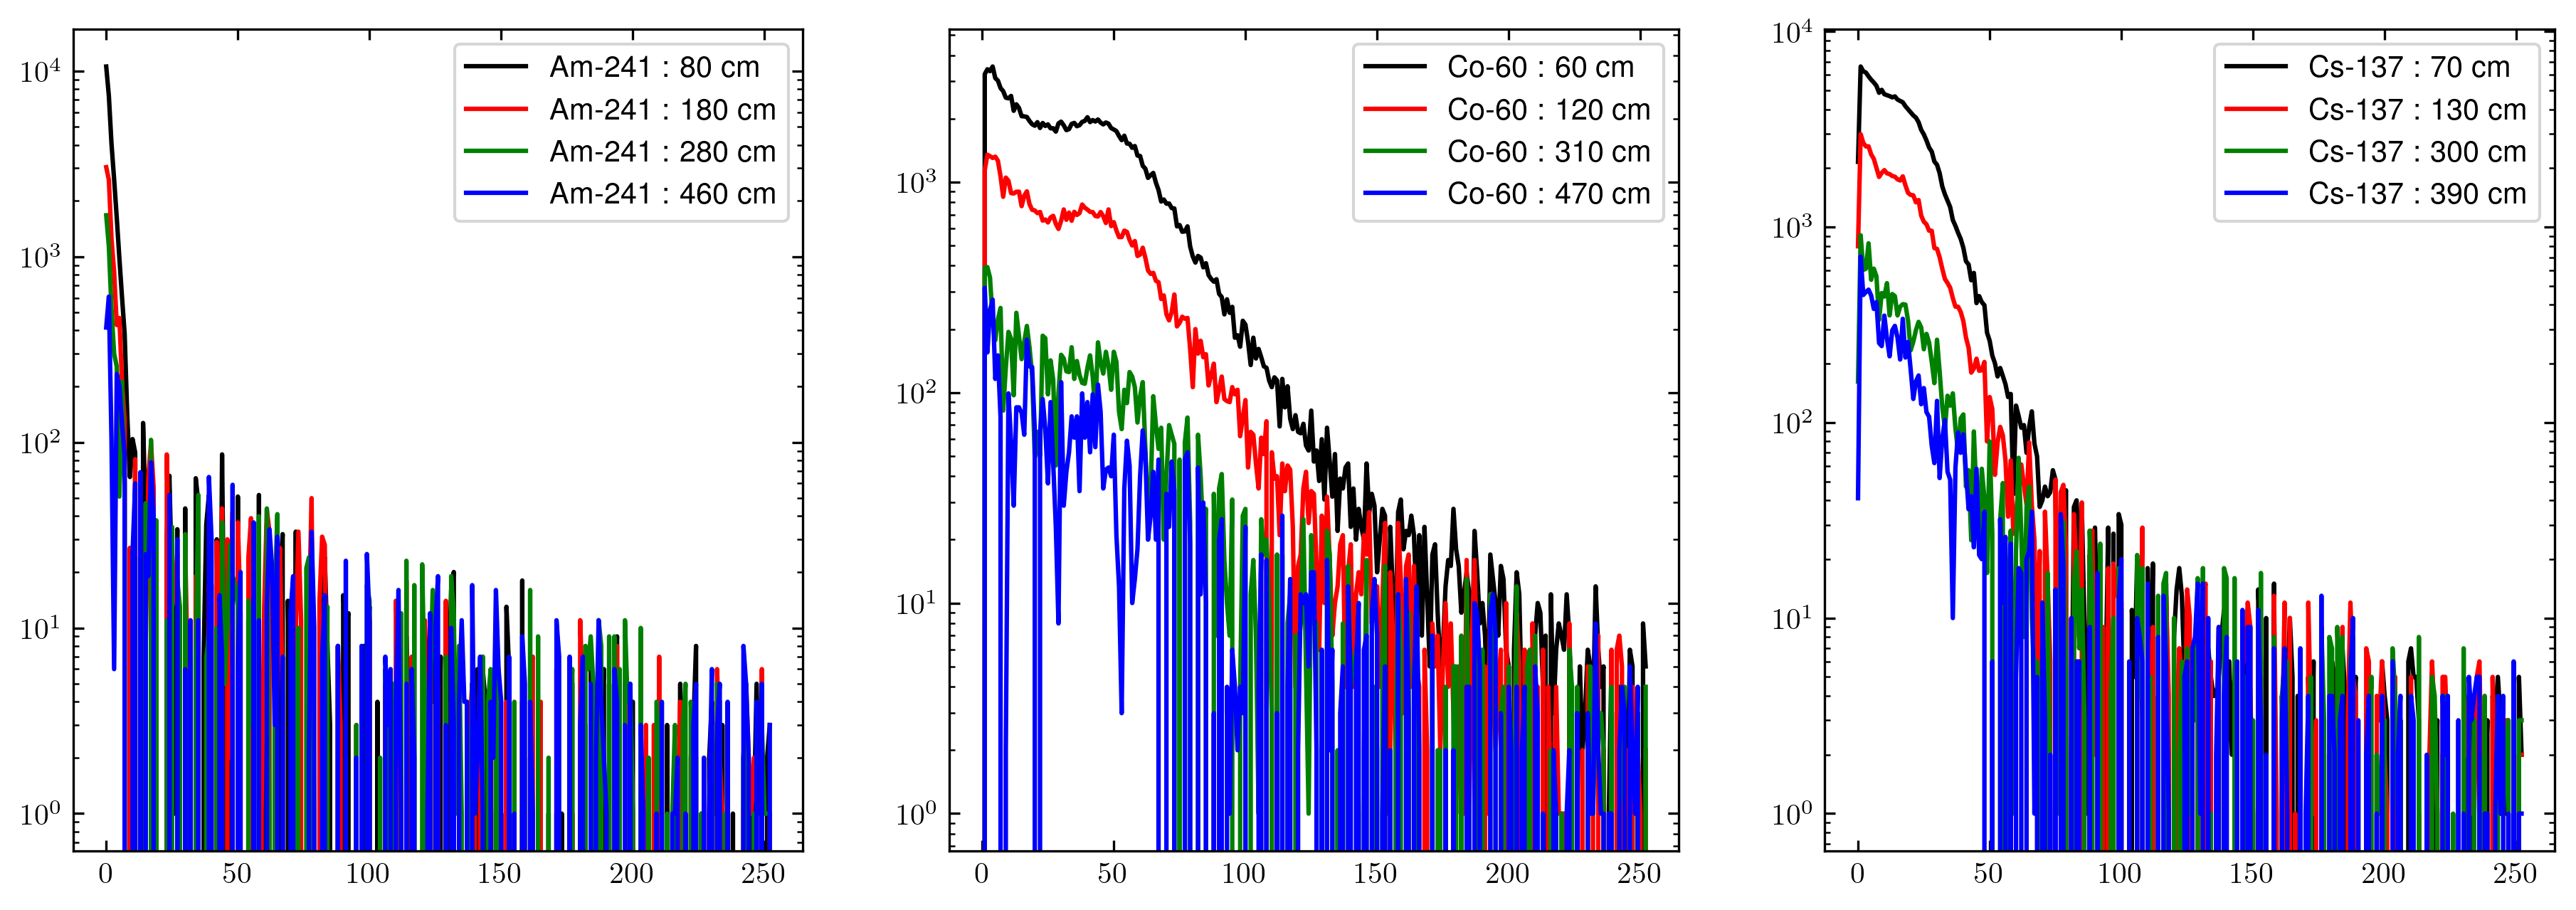

In [2]:
plt.figure(figsize=(15, 5), dpi=300)

plt.subplot(131)
plt.plot(SpecsRefBkg['am_80'] ,color="black", label = "Am-241 : 80 cm" )
plt.plot(SpecsRefBkg['am_180'], color="red", label = "Am-241 : 180 cm")
plt.plot(SpecsRefBkg['am_280'], color = "green", label = "Am-241 : 280 cm" )
plt.plot(SpecsRefBkg['am_460'], color="blue", label = "Am-241 : 460 cm" )
plt.semilogy()
plt.legend()

plt.subplot(132)
plt.plot(SpecsRefBkg['co_60']  ,color="black", label = "Co-60 : 60 cm" )
plt.plot(SpecsRefBkg['co_120'] ,color="red", label = "Co-60 : 120 cm")
plt.plot(SpecsRefBkg['co_310'] ,color="green", label = "Co-60 : 310 cm")
plt.plot(SpecsRefBkg['co_470'] ,color="blue", label = "Co-60 : 470 cm")
plt.semilogy()
plt.legend()

plt.subplot(133)
plt.plot(SpecsRefBkg['cs_70']  ,color="black", label = "Cs-137 : 70 cm" )
plt.plot(SpecsRefBkg['cs_130'] ,color="red", label = "Cs-137 : 130 cm")
plt.plot(SpecsRefBkg['cs_300'] ,color="green", label = "Cs-137 : 300 cm")
plt.plot(SpecsRefBkg['cs_390'] ,color="blue", label = "Cs-137 : 390 cm")
plt.semilogy()
plt.legend()

In [3]:
def solidangle(z=80):
    theta = np.pi/2 - np.arctan2(90, z)
    phi = np.arctan2(15, z)
    return (4*phi * np.cos(theta))/4/np.pi

In [4]:
solidangle(470)/solidangle(80)


np.float64(0.04331362053530168)

In [5]:
print("| %8s | %13s | %9s | %18s | %10s | %15s |"%("Isotope", "Distance (cm)", "(d_0/d)^2", "Solid angle ratio", "Count sum", "Count sum ratio"))
for kk in SpecsRefBkg.keys():
    xs = kk.split("_")
    nn, d = (xs[0], int(xs[1]))
    if nn == "am" :
        specsum = sum(SpecsRefBkg[kk])/sum(SpecsRefBkg["am_80"])
        sangle = solidangle(d)/solidangle(80)
        invdsq = (80/d)**2
    elif nn == "co" :
        specsum = sum(SpecsRefBkg[kk])/sum(SpecsRefBkg["co_60"])
        sangle = solidangle(d)/solidangle(60)
        invdsq = (60/d)**2
    elif nn == "cs" :
        specsum = sum(SpecsRefBkg[kk])/sum(SpecsRefBkg["cs_70"])
        sangle = solidangle(d)/solidangle(70)
        invdsq = (70/d)**2
    
    
    print("| %8s | %13d | %9.6f | %18.8f | %10d | %15.5f |"%(nn, d, invdsq, sangle, sum(SpecsRefBkg[kk]), specsum))
    
    
    

|  Isotope | Distance (cm) | (d_0/d)^2 |  Solid angle ratio |  Count sum | Count sum ratio |
|       am |            80 |  1.000000 |         1.00000000 |      28696 |         1.00000 |
|       am |           180 |  0.197531 |         0.26840164 |       9286 |         0.32360 |
|       am |           280 |  0.081633 |         0.11822422 |       3949 |         0.13761 |
|       am |           460 |  0.030246 |         0.04518151 |       1292 |         0.04502 |
|       co |            60 |  1.000000 |         1.00000000 |     145139 |         1.00000 |
|       co |           120 |  0.250000 |         0.36604683 |      53257 |         0.36694 |
|       co |           310 |  0.037461 |         0.06613354 |       9904 |         0.06824 |
|       co |           470 |  0.016297 |         0.02943696 |       4977 |         0.03429 |
|       cs |            70 |  1.000000 |         1.00000000 |     151193 |         1.00000 |
|       cs |           130 |  0.289941 |         0.39242688 |      601

In [6]:
def Omega(d=80):
    a=90.0
    b=15.0
    return 4*np.arcsin(a*b/np.sqrt((a**2+d**2)*((b**2+d**2))))

In [7]:
Omega(470)/Omega(60)

np.float64(0.029524453052047893)

| RadionuRadionuclide | Distance (cm)  | Inverse-square estimate | Finite-detector solid-angle estimate | Normalized measured  response | Top-rank stability (%)  |
|:---------|:---------:|:---------:|:---------:|:---------:|:---------:|
| Am-241 | 80 | 1.000  | 1.000  | 1.000  | 100.00 | 
| Am-241| 180 |  0.198 |  0.269  | 0.316 |  100.00 |
| Am-241 | 280 | 0.082 | 0.118 | 0.129  | 100.00  |
| Am-241 | 460 | 0.030  | 0.045 | 0.042  | 96.86 | 
| Cs-137 | 70  | 3.449 | 2.545  | 2.581  | 100.00  | 
| Cs-137 | 130 | 1.000  | 1.000  | 1.000  | 100.00  | 
| Cs-137 | 300 |  0.188 | 0.220 | 0.220  | 100.00  | 
| Cs-137 | 390 |  0.111  | 0.132 | 0.128  | 99.84 | 
| Co-60 | 60 | 4.000 | 2.728 | 2.763 | 100.00 |
| Co-60 | 120 | 1.000 |  1.000 | 1.000 | 100.00 | 
| Co-60 | 310  | 0.150 |  0.181 |  0.183 | 100.00 |
| Co-60 | 470 | 0.065 | 0.081 | 0.074 | 99.84 | 

| RadionuRadionuclide | Distance (cm)  | Inverse-square estimate | Finite-detector solid-angle estimate | Normalized measured  response |
|:---------|:---------:|:---------:|:---------:|:---------:|
| Am-241 | 80 | 1.000  | 1.000  | 1.000  | 
| Am-241| 180 |  0.198 |  0.269  | 0.316 | 
| Am-241 | 280 | 0.082 | 0.118 | 0.129  | 
| Am-241 | 460 | 0.030  | 0.045 | 0.042  | 
| Cs-137 | 70  | 3.449 | 2.545  | 2.581  | 
| Cs-137 | 130 | 1.000  | 1.000  | 1.000  | 
| Cs-137 | 300 |  0.188 | 0.220 | 0.220  | 
| Cs-137 | 390 |  0.111  | 0.132 | 0.128  | 
| Co-60 | 60 | 4.000 | 2.728 | 2.763 | 
| Co-60 | 120 | 1.000 |  1.000 | 1.000 | 
| Co-60 | 310  | 0.150 |  0.181 |  0.183 | 
| Co-60 | 470 | 0.065 | 0.081 | 0.074 |

In [8]:
def Omega(d):
    a=90.0
    b=15.0
    return 4*np.arcsin(a*b/np.sqrt)

In [9]:
_bccsref = {}
for kk in SpecsRefBkg.keys():
    _bccsref[kk] = bccs(SpecsRefBkg[kk])

BCCSRef = pd.DataFrame(_bccsref)

In [18]:
_refspecs =_refspecSub= {"Am" : BCCSRef["am_80"], "Co" :BCCSRef["co_60"], "Cs":BCCSRef["cs_70"]}

dx0 ={ "am": 80, "co":60, "cs": 70}

BCCSFitResult0, BCCSFitResult = {}, {}

for kk in BCCSRef.keys():
    popt, se, pconv = BCCSfit((0.5, 0.5, 0.5), BCCSRef[kk], _refspecSub, 150, False)
    BCCSFitResult0[kk] = (popt, se, pconv)
    BCCSFitResult[kk] = {}
    BCCSFitResult[kk]["am"] = [float(c) for c in (float(popt[0]), float(np.sqrt(se[0])))]
    BCCSFitResult[kk]["co"] = [float(c) for c in (float(popt[1]), float(np.sqrt(se[1])))]
    BCCSFitResult[kk]["cs"] = [float(c) for c in (float(popt[2]), float(np.sqrt(se[2])))]

/Users/jiyong/Documents/Papers/IsotpoeIdentification/papers/ver260803_MoonRevision/analysis/specs.py:380: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pconv = optimization.curve_fit(detfunc, np.arange(len(spectrum[0:idf])), spectrum[0:idf], params, absolute_sigma=True)


In [19]:
print("| %12s | %13s | %13s | %17s | %17s  | %17s  |"%("Isotope", "distance (cm)", "(d_0/d)^2", "Am-241", "Co-60", "Cs-137"))
for kk in BCCSFitResult.keys():
    nn, d0 = kk.split("_")
    dd = int(d0)
    print("| %12s | %13d | %13.8f | %6.3f +/- %6.3f | %6.3f +/- %6.3f | %6.3f +/- %6.3f |"%(nn, dd, (dx0[nn]/dd)**2, BCCSFitResult[kk]["am"][0], BCCSFitResult[kk]["am"][1], BCCSFitResult[kk]["co"][0], BCCSFitResult[kk]["co"][1], BCCSFitResult[kk]["cs"][0], BCCSFitResult[kk]["cs"][1]))

|      Isotope | distance (cm) |     (d_0/d)^2 |            Am-241 |             Co-60  |            Cs-137  |
|           am |            80 |    1.00000000 |  1.000 +/-  0.005 | -0.000 +/-  0.000 |  0.000 +/-  0.000 |
|           am |           180 |    0.19753086 |  0.316 +/-  0.006 |  0.002 +/-  0.002 | -0.000 +/-  0.002 |
|           am |           280 |    0.08163265 |  0.137 +/-  0.005 | -0.000 +/-  0.001 |  0.000 +/-  0.002 |
|           am |           460 |    0.03024575 |  0.051 +/-  0.005 | -0.000 +/-  0.001 |  0.000 +/-  0.001 |
|           co |            60 |    1.00000000 | -0.000 +/-    inf |  1.000 +/-    inf | -0.000 +/-    inf |
|           co |           120 |    0.25000000 |  0.000 +/-  0.005 |  0.358 +/-  0.002 |  0.014 +/-  0.002 |
|           co |           310 |    0.03746098 |  0.011 +/-  0.006 |  0.065 +/-  0.002 |  0.002 +/-  0.002 |
|           co |           470 |    0.01629697 |  0.015 +/-  0.006 |  0.027 +/-  0.002 |  0.005 +/-  0.002 |
|           cs | 

In [12]:
BCCSFitResult

{'am_80': {'am': [0.9999999999999889, 0.0052240702817266055],
  'co': [-7.771263137270564e-16, 0.000161483844940082],
  'cs': [6.105227152763601e-16, 0.0002862802588315904]},
 'am_180': {'am': [0.3163830321503639, 0.00577180336706993],
  'co': [0.0021596540678007524, 0.0016971542184616095],
  'cs': [-1.587444156917369e-10, 0.002197359298174765]},
 'am_280': {'am': [0.13708694245644598, 0.005240048830176448],
  'co': [-4.014467644810906e-11, 0.001322933716019342],
  'cs': [2.39799854579439e-11, 0.0017877264351846619]},
 'am_460': {'am': [0.05146758677021171, 0.0052360109103899224],
  'co': [-3.5131980995690556e-12, 0.0006946332332189021],
  'cs': [1.0818495291067433e-11, 0.0009879260493615642]},
 'co_60': {'am': [-1.887379141862766e-15, inf],
  'co': [0.9999999999999999, inf],
  'cs': [-2.220446049250313e-16, inf]},
 'co_120': {'am': [2.565489756429941e-08, 0.005196582407642129],
  'co': [0.35801751874485455, 0.001801696596794956],
  'cs': [0.013865558481576853, 0.002192017355590143]},


In [17]:
d0

'80'